<a href="https://colab.research.google.com/github/carlosgonzalezalanis-arch/M-todos-n-meros-/blob/main/M%C3%A9todo_de_disecci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***Método de Bisección***

In [ ]:
# Solicitar el grado del polinomio
grado = int(input("Ingresa el grado del polinomio: "))

# Lista para almacenar los coeficientes de mayor a menor grado
coeficientes = []

print("\nIngresa los coeficientes:")
# Bucle para pedir cada coeficiente desde el grado mayor hasta 0
for i in range(grado, -1, -1):
    coef = float(input(f"Coeficiente para x^{i}: "))
    coeficientes.append(coef)

# Imprimir la ecuación con formato
print("\nP(x) = ", end="")

# Recorrer los coeficientes para imprimir cada término
for i in range(grado + 1):
    coef = coeficientes[i]
    potencia = grado - i

    if coef == 0:
        continue

    # Asignar el signo y el valor del coeficiente
    if i == 0:
        print(f"{coef}", end="")
    else:
        if coef > 0:
            print(f" + {coef}", end="")
        else:
            print(f" - {coef * -1}", end="")

    # Asignar la variable x y su exponente
    if potencia > 1:
        print(f"x^{potencia}", end="")
    elif potencia == 1:
        print("x", end="")

print() # Salto de línea al finalizar la impresión

# Función para evaluar el polinomio usando división sintética (método de Horner)
def f_polinomio(x):
    resultado = coeficientes[0]

    # Iterar sobre los coeficientes restantes para calcular el valor
    for i in range(1, grado + 1):
        resultado = (resultado * x) + coeficientes[i]

    return resultado

**DESCRIPCIÓN DEL PROGRAMA:**
Este bloque captura un polinomio ingresado por el usuario y define una función para evaluarlo de forma eficiente utilizando la Regla de Horner (División Sintética).

**SOBRE LA REGLA DE HORNER:**
Para evitar el cálculo repetitivo y lento de potencias (como $x^2$, $x^3$, etc.), la Regla de Horner reescribe el polinomio factorizando y anidando la variable $x$. Por ejemplo, una ecuación como $ax^2 + bx + c$ se evalúa como $(ax + b)x + c$.

En el código, esto se implementa tomando el coeficiente de mayor grado como resultado inicial. Luego, mediante un ciclo, el valor acumulado simplemente se multiplica por $x$ y se le suma el coeficiente siguiente. Esto reduce la cantidad de operaciones matemáticas necesarias y hace que el cálculo sea mucho más rápido y eficiente al integrarse con el método de bisección.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Encapsulamos la lógica en una función reutilizable
def ejecutar_biseccion(a, b, tol, n0):
    a_inicial = a
    b_inicial = b

    # f_polinomio tomará automáticamente los coeficientes globales activos
    fa = f_polinomio(a)
    fb = f_polinomio(b)

    if fa * fb > 0:
        print("\nError: La función no tiene signos opuestos en los extremos.")
        print(f"f({a}) = {fa}")
        print(f"f({b}) = {fb}")
        return

    i = 1
    raiz_aproximada = None

    print(f"\n{'n':>3} | {'a_n':>10} | {'b_n':>10} | {'p_n':>10} | {'f(p_n)':>10}")
    print("-" * 55)

    while i <= n0:
        p = a + (b - a) / 2
        fp = f_polinomio(p)

        print(f"{i:3} | {a:10.7f} | {b:10.7f} | {p:10.7f} | {fp:10.7f}")

        if fp == 0 or (b - a) / 2 < tol:
            raiz_aproximada = p
            print("-" * 55)
            print(f"Procedimiento completado exitosamente. p = {raiz_aproximada:.9f}")
            break

        i += 1

        if fa * fp > 0:
            a = p
            fa = fp
        else:
            b = p

    if raiz_aproximada is None:
        print(f"\nEl método fracasó después de {n0} iteraciones.")
        return

    # --- Graficación Simplificada ---
    # Genera puntos estrictamente dentro del intervalo [a, b]
    x_vals = np.linspace(a_inicial, b_inicial, 400)
    y_vals = f_polinomio(x_vals)

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, y_vals, color='blue', label='P(x)')

    # Dibuja la línea del eje X (y=0) para visualizar dónde cruza la raíz
    plt.axhline(0, color='black', linewidth=1)

    plt.title(f"Gráfica en el intervalo [{a_inicial}, {b_inicial}]")
    plt.xlabel("x")
    plt.ylabel("P(x)")
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

**DESCRIPCIÓN DEL PROGRAMA :**
Este bloque toma la función del polinomio generada en el bloque anterior, aplica el método numérico de bisección para aproximar una raíz dentro de un intervalo específico y finalmente grafica el resultado.

**SOBRE EL MÉTODO DE BISECCIÓN:**
El algoritmo se basa en el teorema del valor intermedio: si la función evaluada en los extremos de un intervalo $[a, b]$ tiene signos opuestos, significa que la curva cruza el eje $x$ al menos una vez en ese espacio.

El método divide el intervalo exactamente a la mitad de forma iterativa. En cada paso, determina en cuál de las dos nuevas mitades ocurre el cambio de signo y descarta la otra. Este proceso de reducir el rango a la mitad se repite hasta que el tamaño del subintervalo es menor que la tolerancia ($TOL$) exigida o hasta encontrar la raíz exacta de forma anticipada.




--- EJEMPLO 1: f(x) = x^3 + 4x^2 - 10 en el intervalo [1, 2] ---

  n |        a_n |        b_n |        p_n |     f(p_n)
-------------------------------------------------------
  1 |  1.0000000 |  2.0000000 |  1.5000000 |  2.3750000
  2 |  1.0000000 |  1.5000000 |  1.2500000 | -1.7968750
  3 |  1.2500000 |  1.5000000 |  1.3750000 |  0.1621094
  4 |  1.2500000 |  1.3750000 |  1.3125000 | -0.8483887
  5 |  1.3125000 |  1.3750000 |  1.3437500 | -0.3509827
  6 |  1.3437500 |  1.3750000 |  1.3593750 | -0.0964088
  7 |  1.3593750 |  1.3750000 |  1.3671875 |  0.0323558
  8 |  1.3593750 |  1.3671875 |  1.3632812 | -0.0321500
  9 |  1.3632812 |  1.3671875 |  1.3652344 |  0.0000720
 10 |  1.3632812 |  1.3652344 |  1.3642578 | -0.0160467
 11 |  1.3642578 |  1.3652344 |  1.3647461 | -0.0079893
 12 |  1.3647461 |  1.3652344 |  1.3649902 | -0.0039591
 13 |  1.3649902 |  1.3652344 |  1.3651123 | -0.0019437
 14 |  1.3651123 |  1.3652344 |  1.3651733 | -0.0009358
--------------------------------------

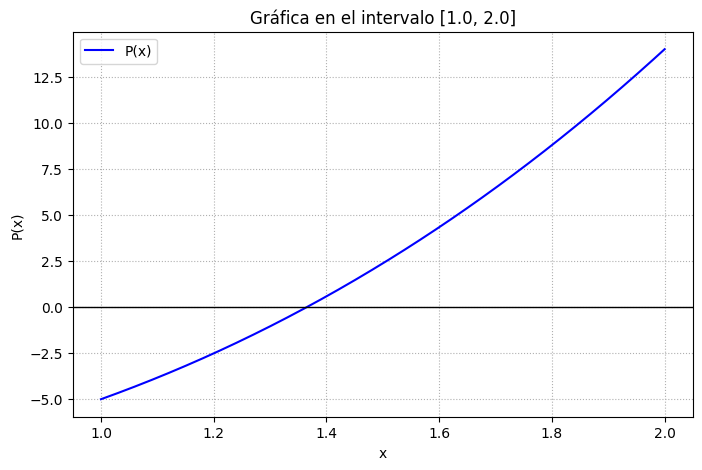

In [13]:
# Ejecución del Ejemplo 1

print("--- EJEMPLO 1: f(x) = x^3 + 4x^2 - 10 en el intervalo [1, 2] ---")

# Definir grado y coeficientes de la ecuación
grado = 3
coeficientes = [1.0, 4.0, 0.0, -10.0]

def f_polinomio(x):
    resultado = coeficientes[0]
    for i in range(1, grado + 1):
        resultado = (resultado * x) + coeficientes[i]
    return resultado

a_ejemplo = 1.0
b_ejemplo = 2.0
tol_ejemplo = 1e-4
iteraciones_ejemplo = 50

# Ejecutar algoritmo
ejecutar_biseccion(a_ejemplo, b_ejemplo, tol_ejemplo, iteraciones_ejemplo)

In [11]:
# --- Ejecución para el ingreso manual (Bloque 1) ---
print("\n--- Parámetros para Bisección (Ingreso Manual) ---")
a_usr = float(input("Límite inferior (a): "))
b_usr = float(input("Límite superior (b): "))
tol_usr = float(input("Tolerancia (TOL): "))
n0_usr = int(input("Número máximo de iteraciones (N0): "))

ejecutar_biseccion(a_usr, b_usr, tol_usr, n0_usr)


--- Parámetros para Bisección (Ingreso Manual) ---


KeyboardInterrupt: Interrupted by user